# 06 — The Mid-Season Exodus: transfer data

Departures come from scraping Transfermarkt's per-club-season transfer pages (summer window = mid-Brasileirão season), cached under `data/raw/tm/`. All logic is in `brasileirao.transfers`; this notebook is narrative + figures only.

In [1]:
from brasileirao import transfers, plotting
import matplotlib.pyplot as plt
import pandas as pd

plotting.style()
dep = transfers.build()          # from cache; re-scrapes only missing pages
fdep = dep[dep.to_foreign]
cs_any = dep.groupby(['club','season']).ngroups
cs_foreign = fdep.groupby(['club','season']).ngroups
print(f'departures: {len(dep)}  (abroad {len(fdep)}, domestic {len(dep)-len(fdep)})')
print(f'club-seasons with >=1 departure abroad: {cs_foreign} of 240 '
      f'({cs_foreign/240:.0%}) -- near-universal, so \'sold vs didn\'t\' is not a usable contrast')
print(f'abroad fees present: {fdep.fee_eur.notna().mean():.0%}; '
      f'median EUR {fdep.fee_eur.median():,.0f}, max EUR {fdep.fee_eur.max():,.0f}')
fdep.sort_values('fee_eur', ascending=False).head(8)[['season','club','player','to_club','fee_eur','transfer_type']]

departures: 3426  (abroad 1252, domestic 2174)
club-seasons with >=1 departure abroad: 235 of 240 (98%) -- near-universal, so 'sold vs didn't' is not a usable contrast
abroad fees present: 44%; median EUR 650,000, max EUR 88,000,000


,season,club,player,to_club,fee_eur,transfer_type
547,2013,Santos,Neymar,Barcelona,88000000.0,permanent
3372,2024,Palmeiras,Endrick,Real Madrid,47500000.0,permanent
1970,2018,Flamengo,Vinicius Junior,Real Madrid,45000000.0,permanent
2368,2019,Santos,Rodrygo,Real Madrid,45000000.0,permanent
167,2012,Internacional,Oscar,Chelsea,32000000.0,permanent
1996,2018,Gremio,Arthur Melo,Barcelona,31000000.0,permanent
1528,2016,Santos,Gabriel Barbosa,Inter,29500000.0,permanent
317,2013,Atletico-MG,Bernard,Shakhtar D.,25000000.0,permanent


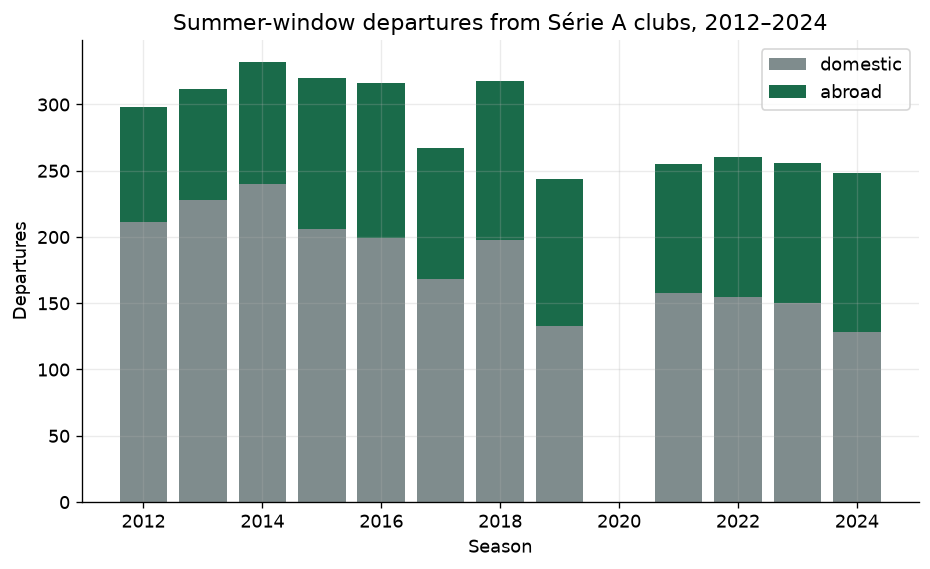

In [2]:
g = dep.groupby(['season','to_foreign']).size().unstack(fill_value=0)
fig, ax = plt.subplots()
ax.bar(g.index, g[False], label='domestic', color=plotting.COLORS['muted'])
ax.bar(g.index, g[True], bottom=g[False], label='abroad', color=plotting.COLORS['main'])
ax.set(title='Summer-window departures from Série A clubs, 2012–2024',
       xlabel='Season', ylabel='Departures')
ax.legend()
plotting.save(fig, 'exodus_departures_by_season')

abroad transfer types: {'loan': 623, 'permanent': 418, 'free': 211}
top destinations abroad: {'Estoril': 21, 'Portimonense': 20, 'Udinese': 16, 'Shakhtar D.': 15, 'Benfica': 13, 'Nacional': 13, 'Santa Clara': 13, 'Porto': 11}


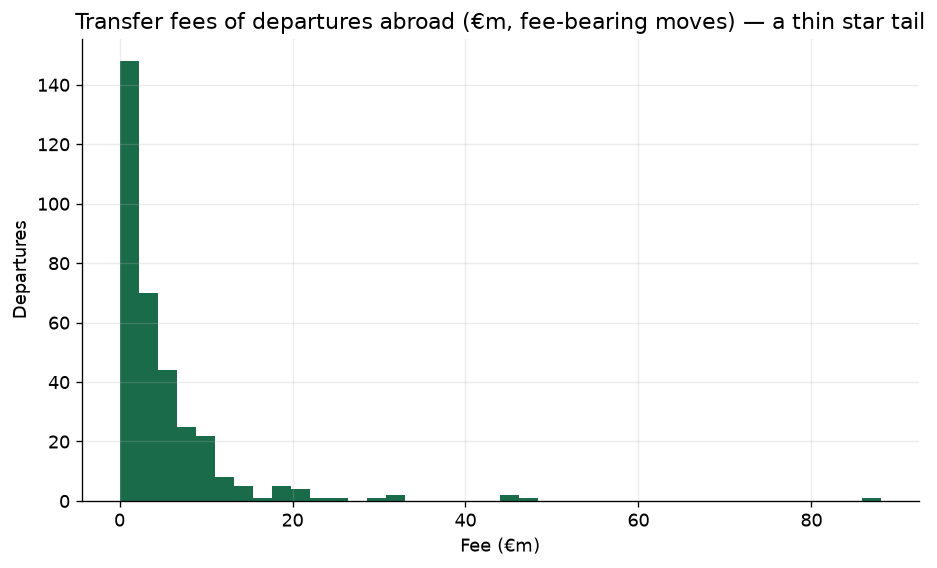

In [3]:
fee_m = fdep['fee_eur'].dropna() / 1e6
fig, ax = plt.subplots()
ax.hist(fee_m[fee_m > 0], bins=40, color=plotting.COLORS['main'])
ax.set(title='Transfer fees of departures abroad (€m, fee-bearing moves) — a thin star tail',
       xlabel='Fee (€m)', ylabel='Departures')
plotting.save(fig, 'exodus_fee_distribution')
print('abroad transfer types:', fdep.transfer_type.value_counts().to_dict())
print('top destinations abroad:', fdep.to_club.value_counts().head(8).to_dict())